In [1]:
import math
import pandas as pd
import numpy as np
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import Rbeast as rb

from shapely.geometry import box
from statsmodels.tsa.seasonal import STL
from matplotlib.ticker import MaxNLocator
from pyproj import Transformer
from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [4]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)
df_m.columns = df_m.columns.astype(int)

brac = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'cr_flow.csv', index_col=1, parse_dates=[1])
brac = brac.drop(columns=['Unnamed: 0'])
brac = brac.resample("MS").mean()
brac.index = brac.index + pd.Timedelta(days=14)
brac = brac.loc['2005':]

krns = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'krns.csv', index_col=0, parse_dates=[0])
krns.index = krns.index + pd.Timedelta(days=14)

Exception ignored in PyObject_HasAttrString(); consider using PyObject_HasAttrStringWithError(), PyObject_GetOptionalAttrString() or PyObject_GetAttrString():
Traceback (most recent call last):
  File "/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/beast.py", line 498, in beast
    o = cbeast.Rbeast('beast_'+method,Y, metadata, prior, mcmc, extra) 
SystemError: /home/conda/feedstock_root/build_artifacts/python-split_1765018748003/work/Objects/dictobject.c:4167: bad argument to internal function


INFO: Your metadata$startTime=[2005,1,15] is interpreted as 2005/01/15 (Year/Month/Day) and converted to a decimal year of 2005.04. If not making sense, supply a correct start time using one of the following for startTime:  
(1) a numeric scalar (e.g., 2002.33)
(2) a vector of two values (Year, Month) (e.g., c(2002,4) in R, [2002,4] in Matlab/Python) 
(3) a vector of three values (Year, Month, Day) (e.g., c(2002,4,15) in R,  [2002,4,15] in Matlab/Python)
(4) a date string (e.g., "2002-4-15", "2002/04/15", or "2002/4")
(5) a datenum as a list/struct variable (e.g., list(datenum=12523, origin='R') or struct('datenum', 731321, 'origin','matlab')


Model fitted:  Y =  trend + season + error 

INFO: To supress messages, set print_param/print_warning/print_progresss = 0 in beast() and beast_irreg()
INFO: To supress messages, Set extra.printParameter/printWarning/printProgress = 0 in beast123()
INFO: To supress all messaages, set quiet=1 in beast() and beast_irreg() or extra.quiet=1 in beast1

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/Rbeast/plotbeast.py:1015: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


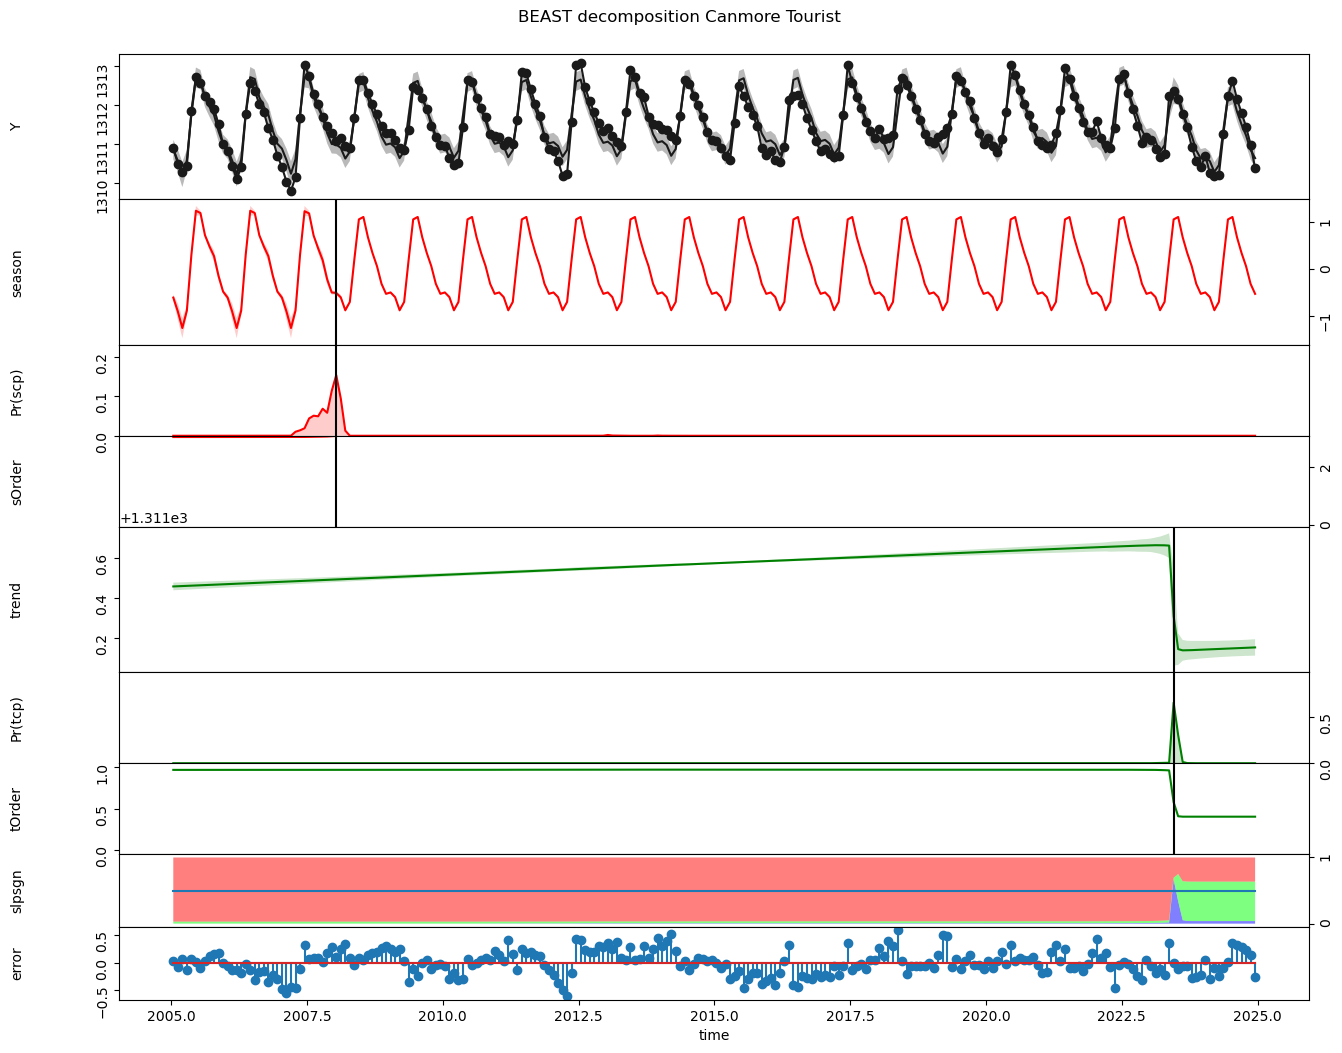

In [6]:
y = df_m[760].values
o = rb.beast(
    y,
    start=[2005, 1, 15],
    deltat="1 month",
    period="1 year",
    season="harmonic",
    tcp_minmax=[0,1],
    scp_minmax=[0,10],
)

rb.plot(o, title=f"BEAST decomposition Canmore Tourist")
fig = plt.gcf()
fig.set_size_inches(14, 11)